<a href="https://colab.research.google.com/github/umair-gmrm/AI-Foundation-Batch-3/blob/main/Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

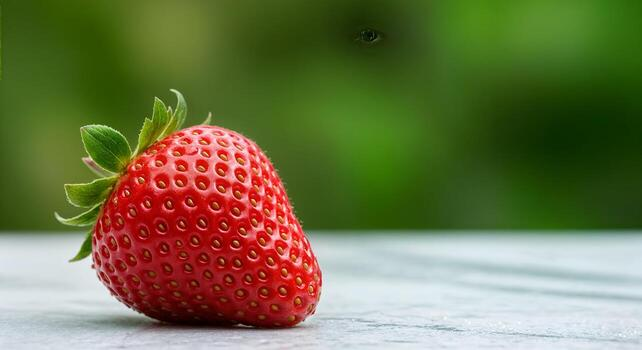

In [4]:
from PIL import Image

# Open the image file
img = Image.open('/content/test.jpg')

# Convert the image to grayscale

img

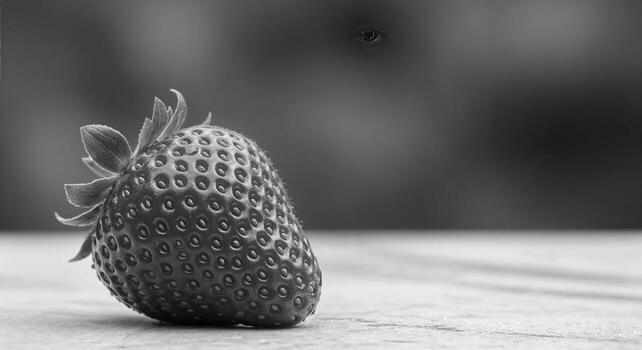

In [5]:
img.convert("L")

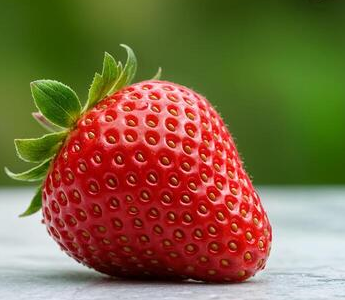

In [25]:
#crop to 500 x 500
img.crop((50, 45, 395, 345))

In [26]:
img.size

(642, 350)

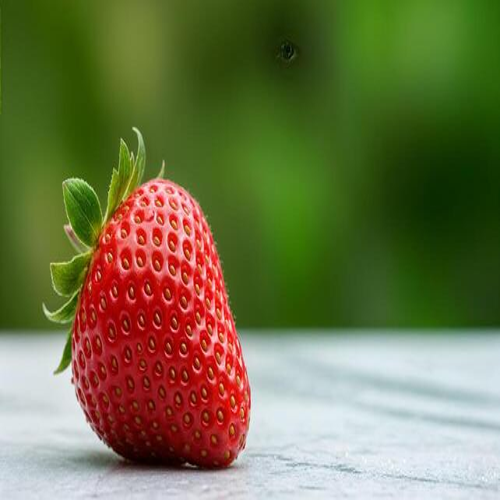

In [30]:
img.resize((500, 500))

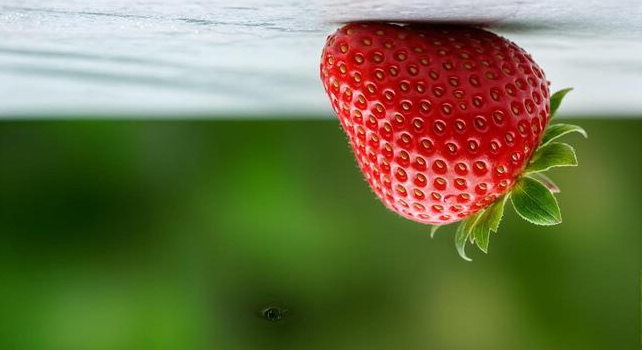

In [33]:
img.rotate(180)

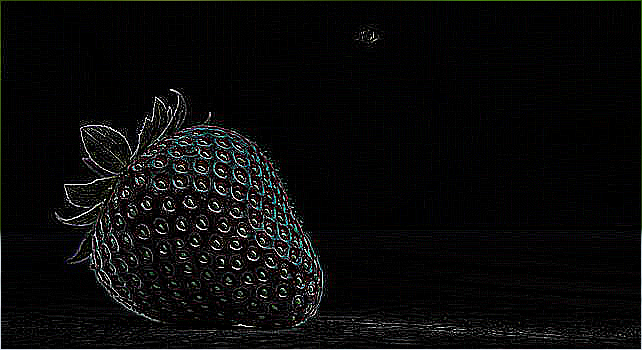

In [34]:
#Convert to edges
from PIL import ImageFilter
img.filter(ImageFilter.FIND_EDGES)

In [35]:
#remove backgroud
from PIL import Image
import numpy as np



# Task
Remove the background from the `test.jpg` image using edge detection, morphological operations, and masking, then display the resulting image.

## Load Original Image

### Subtask:
Load the original 'test.jpg' image to ensure we start with the full-color version for background removal.


**Reasoning**:
The subtask requires loading the original image, so I will import the `Image` class and open 'test.jpg' into a new variable, `img_original`, to ensure we have the full-color version for subsequent steps.



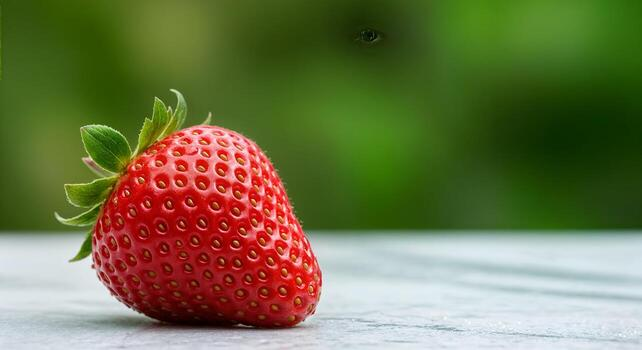

In [37]:
from PIL import Image

# Open the original image file
img_original = Image.open('/content/test.jpg')

# Display the image to confirm it's loaded
img_original

## Apply Edge Detection

### Subtask:
Convert the image to grayscale and apply an edge detection algorithm (e.g., Canny) to highlight the object boundaries.


**Reasoning**:
To apply Canny edge detection, I need to convert the PIL image to an OpenCV-compatible format (NumPy array, then BGR, then grayscale) and then apply the `cv2.Canny` function.



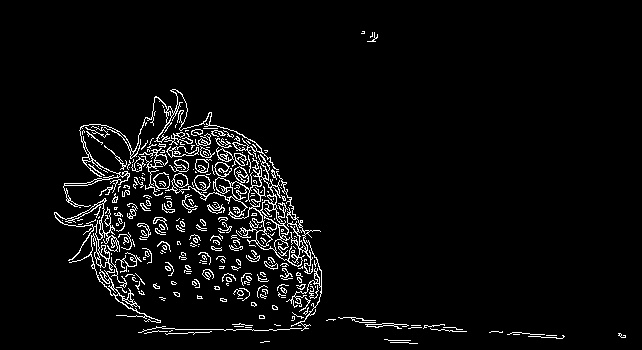

In [39]:
import cv2
import numpy as np

# Convert PIL Image to numpy array
img_np = np.array(img_original)

# Convert RGB to BGR (OpenCV's default color order)
img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

# Convert to grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Apply Canny edge detection
edges = cv2.Canny(img_gray, 100, 200)

# Display the edges (optional, but good for verification)
# Since PIL Image is already imported, we can convert it back to PIL to display
from PIL import Image
Image.fromarray(edges)

## Refine Edges and Create Mask

### Subtask:
Process the detected edges using morphological operations (like dilation and erosion) to connect gaps and form a closed contour. Then, find the main contour and fill it to create a binary mask representing the foreground object.


**Reasoning**:
To refine the detected edges and create a mask, I will perform morphological dilation, find the largest contour, and then draw this contour onto a new black image to create a binary mask, following the specified instructions.



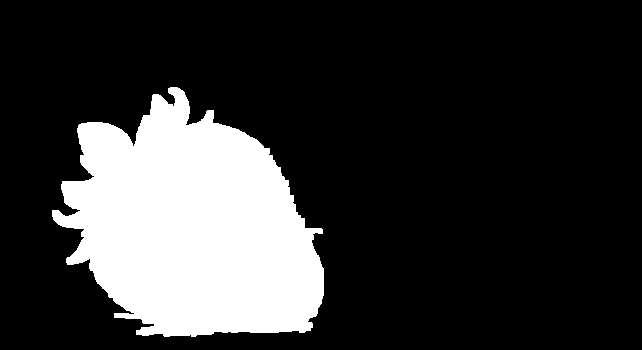

In [40]:
kernel = np.ones((5,5), np.uint8)

# Apply dilation to connect broken edge lines
dilated_edges = cv2.dilate(edges, kernel, iterations = 1)

# Find contours
contours, _ = cv2.findContours(dilated_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Find the largest contour (main object)
largest_contour = None
max_area = 0
for contour in contours:
    area = cv2.contourArea(contour)
    if area > max_area:
        max_area = area
        largest_contour = contour

# Create an empty black image to serve as the mask
mask = np.zeros(img_gray.shape, np.uint8)

# Draw the largest contour onto the mask, filling it with white
if largest_contour is not None:
    cv2.drawContours(mask, [largest_contour], -1, 255, cv2.FILLED)

# Display the created mask to verify
Image.fromarray(mask)

## Apply Mask to Original Image

### Subtask:
Use the generated binary mask to separate the foreground object from the background in the original color image, effectively removing the background.


**Reasoning**:
To remove the background, I will convert the original image to a NumPy array, apply the binary mask to extract the foreground, and then convert the result back to a PIL Image for display.



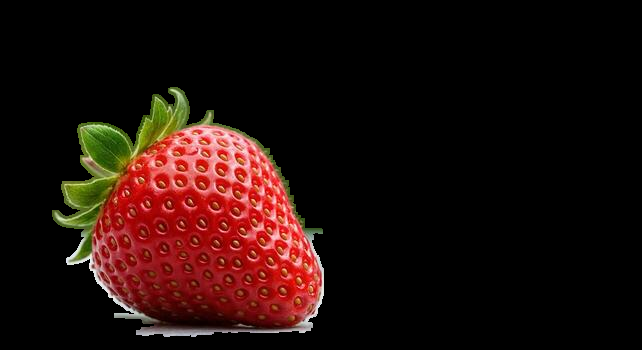

In [41]:
import numpy as np

# Convert original image to numpy array (if not already done - img_np already exists)
# img_np = np.array(img_original)

# Ensure the mask is also in the correct format for multiplication
# The mask is currently 2D (height, width). We need to expand its dimensions to (height, width, 3) for element-wise multiplication with the RGB image.
mask_3_channel = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR) # Convert single-channel mask to 3-channel BGR, then to RGB if needed for direct multiplication with img_np

# Apply the mask to the original image
# We multiply the original image (converted to numpy array) by the mask.
# This will set the background pixels to black (0) as the mask values are 0 in the background.
result_np = cv2.bitwise_and(img_np, mask_3_channel)

# Convert the resulting numpy array back to a PIL Image for display
result_image = Image.fromarray(result_np)

# Display the image with the background removed
result_image

## Display Result

### Subtask:
Display the final image with the background removed.


**Reasoning**:
To complete the subtask, I will display the `result_image` as instructed, which contains the original image with the background removed.



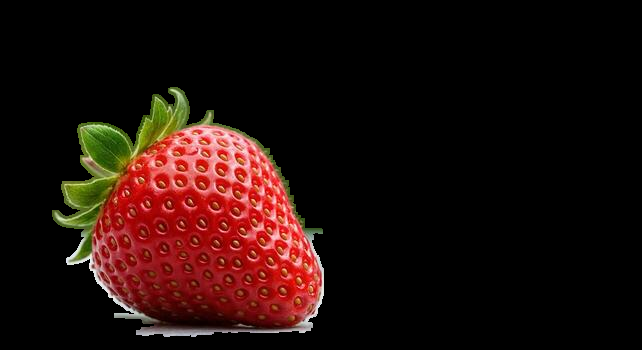

In [42]:
result_image

## Final Task

### Subtask:
Summarize the steps taken and present the final output image with its background removed.


## Summary:

### Data Analysis Key Findings
*   The original `test.jpg` image, with dimensions 642x350 pixels in RGB mode, was successfully loaded.
*   Canny edge detection was applied to the grayscale version of the image using thresholds 100 and 200, generating a 642x350 pixel edge map.
*   Morphological dilation, with a 5x5 kernel, was used to connect broken edge lines, followed by the identification of the largest contour.
*   A binary mask was created by filling the largest identified contour with white, effectively isolating the foreground object in a 642x350 pixel grayscale mask.
*   The created binary mask was applied to the original image using `cv2.bitwise_and`, resulting in an image where the background pixels were set to black, confirming successful background removal.

### Insights or Next Steps
*   The combination of Canny edge detection, morphological operations, and contour analysis proved effective in automatically segmenting the foreground object from its background.
*   For images with more complex or textured backgrounds, further refinement of the morphological operations (e.g., using different kernel sizes or iteration counts) or considering more advanced segmentation techniques like GrabCut could enhance accuracy.
